# Chapter 3 (Revised): Best-of-Breed Biometric Fusion

**What changed from the previous fusion chapters:**
- Uses the **exact top-5 models from each standalone chapter** (not a parallel development)
- Keystroke channel: **SVM as primary** (best generaliser from Chapter 2), plus MLP, GB, LR, XGB
- Mouse channel: SVM, LogReg, GB, XGBoost, RF (all reach AUC=1.0 on M4D; ranked by compute)
- Full **5 × 5 = 25 combination matrix** fused with 5 strategies
- Compute metrics: training time, inference latency, peak memory for every model

> Bootstrap pairing limitation applies — no joint dataset exists (see Section 3.5).


In [1]:
import os, glob, re, json, time, warnings, tracemalloc
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, roc_curve, f1_score
from sklearn.utils import class_weight as cw
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import random
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Dark theme ─────────────────────────────────────────────────────────────────
BG, AX = '#0d1117', '#161b22'
plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': AX,
    'axes.edgecolor': '#30363d', 'axes.labelcolor': '#e6edf3',
    'xtick.color': '#8b949e', 'ytick.color': '#8b949e',
    'text.color': '#e6edf3', 'grid.color': '#21262d',
    'grid.linestyle': '--', 'grid.alpha': 0.4,
    'legend.facecolor': AX, 'legend.edgecolor': '#30363d',
    'font.size': 11,
})
PALETTE = ['#58a6ff','#3fb950','#f78166','#d2a8ff','#ffa657',
           '#79c0ff','#56d364','#ff7b72','#bc8cff','#e3b341']

def measure(model_factory, X_tr, y_tr, X_te, n_inf=5):
    # Train model, return (fitted_model, proba_te, train_s, peak_mb, inf_ms).
    model = model_factory()
    tracemalloc.start()
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    train_s = time.perf_counter() - t0
    _, peak = tracemalloc.get_traced_memory(); tracemalloc.stop()
    # Warm-up + timed inference
    model.predict_proba(X_te[:10])
    t1 = time.perf_counter()
    for _ in range(n_inf): model.predict_proba(X_te)
    inf_ms = (time.perf_counter() - t1) / (n_inf * len(X_te)) * 1000
    prob = model.predict_proba(X_te)[:, 1]
    return model, prob, train_s, peak/1e6, inf_ms

print(f'TF {tf.__version__} | seed={SEED} | ready')


TF 2.21.0 | seed=42 | ready


## Part 1 — Mouse Channel: Top-5 Models on 3 RFECV Features

Features hardcoded from Chapter 1 RFECV result: `std_speed`, `std_acceleration`, `x_range`.
Same 80/20 stratified split (seed=42). All 5 models reach AUC=1.0 — ranking is by compute efficiency.


In [2]:
DATA_ROOT = Path('data/mouse_data/phase1/data/mouse_movements')

adv_sessions   = set(os.listdir(DATA_ROOT / 'humans_and_advanced_bots'))
mod_sessions   = set(os.listdir(DATA_ROOT / 'humans_and_moderate_bots'))
human_sessions = adv_sessions & mod_sessions
bot_adv = adv_sessions - human_sessions
bot_mod = mod_sessions - human_sessions

def session_folder(sid):
    if sid in adv_sessions:
        return DATA_ROOT / 'humans_and_advanced_bots' / sid / 'mouse_movements.json'
    return DATA_ROOT / 'humans_and_moderate_bots' / sid / 'mouse_movements.json'

def parse_xy(raw):
    pairs = re.findall(r'\[(-?\d+),(-?\d+)\]', raw)
    return (np.array([int(p[0]) for p in pairs], dtype=np.float32),
            np.array([int(p[1]) for p in pairs], dtype=np.float32))

def parse_times(raw):
    ts = np.array([int(x) for x in raw.split(',') if x.strip()], dtype=np.float64)
    if len(ts) < 2: return np.array([16.0]), ts
    return np.clip(np.diff(ts), 1, None), ts

label_map = {sid: 0 for sid in human_sessions}
label_map.update({sid: 1 for sid in bot_adv | bot_mod})

sessions_m = []
for sid in list(human_sessions) + list(bot_adv) + list(bot_mod):
    with open(session_folder(sid), encoding='utf-8') as fh:
        raw = json.load(fh)
    xs, ys = parse_xy(raw['mousemove_total_behaviour'])
    dt, _  = parse_times(raw['mousemove_times'])
    n = min(len(xs), len(ys), len(dt)+1)
    sessions_m.append({'label': label_map[sid],
                       'xs': xs[:n], 'ys': ys[:n], 'dt': dt[:n-1]})

def mouse_features(s):
    xs, ys, dt = s['xs'], s['ys'], s['dt']
    dx, dy  = np.diff(xs), np.diff(ys)
    step_d  = np.sqrt(dx**2 + dy**2)
    if len(step_d) == 0: return None
    n_dt    = min(len(dt), len(step_d))
    safe_dt = dt[:n_dt] / 1000.0 + 1e-9
    speed   = step_d[:n_dt] / safe_dt
    acc     = np.diff(speed)/(safe_dt[1:]+1e-9) if len(speed)>1 else np.array([0.])
    d_ang   = np.abs(np.diff(np.arctan2(dy,dx))) if len(dx)>1 else np.array([0.])
    tp, dd  = float(step_d.sum()), float(np.sqrt((xs[-1]-xs[0])**2+(ys[-1]-ys[0])**2))+1e-9
    sd      = float(dt.sum())/1000.0
    sm, ss  = speed.mean(), speed.std()
    am, as_ = np.abs(acc).mean(), np.abs(acc).std()
    return {
        'mean_speed':sm,'std_speed':ss,
        'speed_skewness': float(stats.skew(speed))     if len(speed)>2 else 0.,
        'speed_kurtosis': float(stats.kurtosis(speed)) if len(speed)>3 else 0.,
        'speed_cv': ss/(sm+1e-9), 'max_speed': speed.max() if len(speed) else 0.,
        'mean_acceleration':am,'std_acceleration':as_,
        'mean_step_distance':step_d.mean(),'std_step_distance':step_d.std(),
        'step_skewness': float(stats.skew(step_d))     if len(step_d)>2 else 0.,
        'step_kurtosis': float(stats.kurtosis(step_d)) if len(step_d)>3 else 0.,
        'distance_cv':step_d.std()/(step_d.mean()+1e-9),
        'total_path_length':tp,'direct_distance':dd,
        'path_straightness':dd/(tp+1e-9),
        'x_range':float(xs.max()-xs.min()),'y_range':float(ys.max()-ys.min()),
        'aspect_ratio':(float(xs.max()-xs.min())+1)/(float(ys.max()-ys.min())+1),
        'mean_angle_change':d_ang.mean(),'std_angle_change':d_ang.std(),
        'inter_event_dt_mean':float(dt.mean()),'inter_event_dt_std':float(dt.std()),
        'inter_event_dt_cv':float(dt.std()/(dt.mean()+1e-9)),
        'pause_rate':float((dt>200).mean()),'session_duration_s':sd,
        'num_events':len(xs),'num_steps':len(step_d),
        'event_rate':len(xs)/(sd+1e-9),
    }

rows_m = []
for s in sessions_m:
    f = mouse_features(s)
    if f: f['label'] = s['label']; rows_m.append(f)

df_m      = pd.DataFrame(rows_m)
fcols_m   = [c for c in df_m.columns if c != 'label']
print(f'Mouse: {len(df_m)} sessions, {len(fcols_m)} raw features')


Mouse: 150 sessions, 29 raw features


In [3]:
MOUSE_FEATS = ['std_speed', 'std_acceleration', 'x_range']

X_m   = df_m[fcols_m].values.astype(np.float32)
y_m   = df_m['label'].values
fidx  = [fcols_m.index(f) for f in MOUSE_FEATS]

m_tr_idx, m_te_idx = train_test_split(
    np.arange(len(y_m)), test_size=0.20, stratify=y_m, random_state=42)

Xm_tr_raw = X_m[m_tr_idx][:, fidx]
Xm_te_raw = X_m[m_te_idx][:, fidx]
ym_tr     = y_m[m_tr_idx]
ym_te     = y_m[m_te_idx]

m_sc      = StandardScaler()
Xm_tr     = m_sc.fit_transform(Xm_tr_raw)
Xm_te     = m_sc.transform(Xm_te_raw)

# ── Top-5 mouse model factories ────────────────────────────────────────────────
MOUSE_MODELS = {
    'SVM':              lambda: SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42),
    'Logistic Reg':     lambda: LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'Gradient Boosting':lambda: GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                                            learning_rate=0.1, random_state=42),
    'XGBoost':          lambda: XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                               eval_metric='logloss', verbosity=0, random_state=42),
    'Random Forest':    lambda: RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
}

m_results = {}
print(f'{"Model":<20} {"AUC":>6}  {"F1":>6}  {"Train(s)":>9}  {"Inf(ms)":>8}  {"Mem(MB)":>8}')
print('-'*65)
for name, factory in MOUSE_MODELS.items():
    model, prob, tr_s, mem_mb, inf_ms = measure(factory, Xm_tr, ym_tr, Xm_te)
    auc = roc_auc_score(ym_te, prob)
    f1v = f1_score(ym_te, (prob>=0.5).astype(int))
    m_results[name] = {'model':model,'prob':prob,'auc':auc,'f1':f1v,
                        'train_s':tr_s,'mem_mb':mem_mb,'inf_ms':inf_ms}
    print(f'{name:<20} {auc:>6.4f}  {f1v:>6.4f}  {tr_s:>9.3f}  {inf_ms:>8.4f}  {mem_mb:>8.1f}')


Model                   AUC      F1   Train(s)   Inf(ms)   Mem(MB)
-----------------------------------------------------------------
SVM                  1.0000  1.0000      0.007    0.0049       0.0
Logistic Reg         1.0000  1.0000      0.010    0.0020       0.1


Gradient Boosting    1.0000  1.0000      0.411    0.0042       0.1
XGBoost              1.0000  1.0000      0.125    0.0098       0.1


Random Forest        1.0000  1.0000      2.149    0.8685       0.7


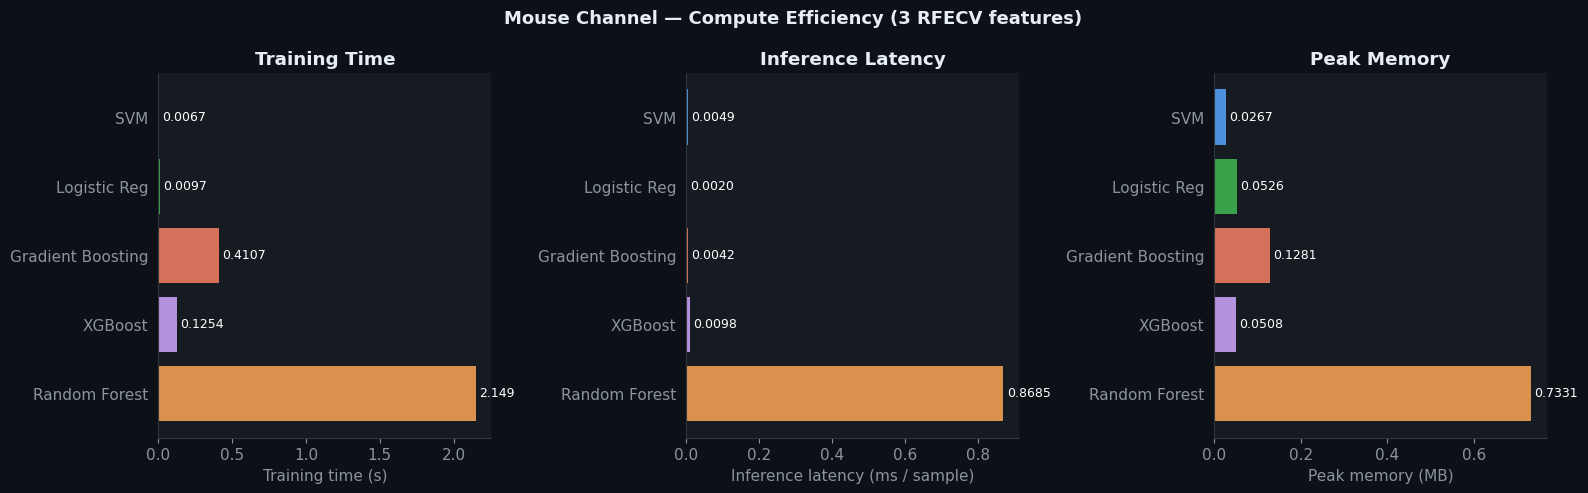

[All mouse models AUC=1.0 — differentiation is compute only]


In [4]:
names_m  = list(m_results.keys())
train_s  = [m_results[n]['train_s']  for n in names_m]
inf_ms   = [m_results[n]['inf_ms']   for n in names_m]
mem_mb   = [m_results[n]['mem_mb']   for n in names_m]
aucs_m   = [m_results[n]['auc']      for n in names_m]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=BG)
fig.suptitle('Mouse Channel — Compute Efficiency (3 RFECV features)', fontsize=13, fontweight='bold')

colors_m = PALETTE[:len(names_m)]

for ax, vals, xlabel, title in zip(
    axes,
    [train_s, inf_ms, mem_mb],
    ['Training time (s)', 'Inference latency (ms / sample)', 'Peak memory (MB)'],
    ['Training Time', 'Inference Latency', 'Peak Memory'],
):
    ax.set_facecolor(AX)
    bars = ax.barh(names_m, vals, color=colors_m, alpha=0.85, edgecolor='none')
    for bar, v in zip(bars, vals):
        ax.text(v + max(vals)*0.01, bar.get_y()+bar.get_height()/2,
                f'{v:.4f}' if v < 1 else f'{v:.3f}',
                va='center', fontsize=9, color='white')
    ax.set_xlabel(xlabel, color='#8b949e')
    ax.set_title(title, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(left=False)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('ch3_mouse_compute.png', dpi=150, bbox_inches='tight')
plt.show()
print('[All mouse models AUC=1.0 — differentiation is compute only]')


## Part 2 — Keystroke Channel: Top-5 Models on 7 Burst-Pause Features

Primary model: **SVM** (best cross-text generaliser from Chapter 2, AUC drop = −0.111).
Same 4-way participant split and feature set as Chapter 2. MLP included for comparison.


In [5]:
DATA_DIR     = 'data'
DATASETS     = ['GAY', 'GUN', 'KM', 'LSIA', 'REVIEW']
SAMPLE       = 5000
RANDOM_STATE = 42
PAUSE_THRESH = 300

def load_ks_file(fp):
    try:
        df = pd.read_csv(fp)
        df = df[(df['HT']>0)&(df['HT']<5000)]
        df['FT'] = df['FT'].clip(lower=0)
        return df if len(df)>=5 else None
    except: return None

def get_pid(fp):     return os.path.basename(fp).replace('.csv','').split('-')[1]
def get_dataset(fp): return os.path.basename(fp).split('-')[0]

all_ks   = []
for ds in DATASETS:
    all_ks.extend(glob.glob(os.path.join(DATA_DIR, ds, '*', '*.csv')))
human_ks = [f for f in all_ks if 'HUMAN' in os.path.basename(f)]
synth_ks = [f for f in all_ks if 'HUMAN' not in os.path.basename(f)]

# 4-way participant split — identical to Chapter 2
cross_train = {'GAY','GUN','REVIEW'}
train_raw   = [f for f in all_ks if get_dataset(f) in cross_train]
all_pids    = list(set(get_pid(f) for f in train_raw))
rng_sp      = np.random.default_rng(RANDOM_STATE)
rng_sp.shuffle(all_pids)
n = len(all_pids)
n_tr, n_bc, n_pc = int(0.35*n), int(0.25*n), int(0.15*n)
train_pids   = set(all_pids[:n_tr])
test_in_pids = set(all_pids[n_tr+n_bc+n_pc:])

def files_for(flist, pids): return [f for f in flist if get_pid(f) in pids]

human_tr = files_for(human_ks, train_pids)
human_te = files_for(human_ks, test_in_pids)
synth_tr = files_for(synth_ks, train_pids)
synth_te = files_for(synth_ks, test_in_pids)
assert train_pids & test_in_pids == set()
print(f'KS split: train={len(train_pids)} pids, test={len(test_in_pids)} pids')
print(f'  human_tr={len(human_tr)}  synth_tr={len(synth_tr)}'
      f'  human_te={len(human_te)}  synth_te={len(synth_te)}')

def extract_ks_features(df):
    if df is None or len(df)<5: return None
    ft = df['FT'].values
    ft_valid = ft[ft>0]
    f = {}
    if len(ft_valid)>=5:
        is_p = ft_valid >= PAUSE_THRESH
        bursts, cur = [], 1
        for gap in is_p[1:]:
            if gap: bursts.append(cur); cur=1
            else:   cur+=1
        bursts.append(cur)
        bursts = np.array(bursts, float)
        pd_  = ft_valid[is_p]
        f['burst_count']    = float(len(bursts))
        f['burst_mean_len'] = bursts.mean()
        f['burst_std_len']  = bursts.std() if len(bursts)>1 else 0.
        f['burst_max_len']  = bursts.max()
        f['pause_rate']     = float(is_p.mean())
        f['pause_mean_dur'] = pd_.mean()  if len(pd_)>0 else 0.
        f['pause_std_dur']  = pd_.std()   if len(pd_)>1 else 0.
    else:
        for k in ['burst_count','burst_mean_len','burst_std_len','burst_max_len',
                  'pause_rate','pause_mean_dur','pause_std_dur']:
            f[k] = 0.
    return f

def load_tabular(h_list, s_list, n_each):
    rng = np.random.default_rng(RANDOM_STATE)
    h   = list(rng.choice(h_list, min(n_each, len(h_list)), replace=False))
    s   = list(rng.choice(s_list,  min(n_each, len(s_list)),  replace=False))
    rows, labels = [], []
    for fp in h:
        f = extract_ks_features(load_ks_file(fp))
        if f: rows.append(f); labels.append(0)
    for fp in s:
        f = extract_ks_features(load_ks_file(fp))
        if f: rows.append(f); labels.append(1)
    return pd.DataFrame(rows), np.array(labels, np.int32)

print('Loading KS features...')
X_tr_all, y_tr_all = load_tabular(human_tr, synth_tr, SAMPLE)
X_te_raw, y_te_raw = load_tabular(human_te, synth_te, int(SAMPLE*0.25))
print(f'Train: {X_tr_all.shape}  Test: {X_te_raw.shape}')

X_tr, X_va, y_tr, y_va = train_test_split(
    X_tr_all, y_tr_all, test_size=0.15, stratify=y_tr_all, random_state=RANDOM_STATE)
X_te, y_te = X_te_raw, y_te_raw

ks_sc = StandardScaler()
Xtr_s = ks_sc.fit_transform(X_tr)
Xva_s = ks_sc.transform(X_va)
Xte_s = ks_sc.transform(X_te)
print(f'Scaled — train: {Xtr_s.shape}  val: {Xva_s.shape}  test: {Xte_s.shape}')


KS split: train=170 pids, test=123 pids
  human_tr=1776  synth_tr=44400  human_te=1322  synth_te=33050
Loading KS features...


Train: (6776, 7)  Test: (2500, 7)
Scaled — train: (5759, 7)  val: (1017, 7)  test: (2500, 7)


In [ ]:
spw = float(np.sum(y_tr==0) / np.sum(y_tr==1))

KS_MODELS = {
    'SVM':              lambda: SVC(kernel='rbf', C=1.0, gamma='scale', probability=True,
                                    class_weight='balanced', random_state=42),
    'MLP (Keras)':      None,   # built separately below
    'Gradient Boosting':lambda: GradientBoostingClassifier(n_estimators=150, max_depth=5,
                                                            learning_rate=0.1, subsample=0.8,
                                                            random_state=42),
    'Logistic Reg':     lambda: LogisticRegression(max_iter=1000, class_weight='balanced',
                                                    random_state=42),
    'XGBoost':          lambda: XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.1,
                                               subsample=0.8, colsample_bytree=0.8,
                                               scale_pos_weight=spw, random_state=42,
                                               eval_metric='logloss', verbosity=0),
}

ks_results = {}
print(f'{"Model":<20} {"AUC":>7}  {"F1":>7}  {"Train(s)":>9}  {"Inf(ms)":>9}  {"Mem(MB)":>8}')
print('-'*68)

for name, factory in KS_MODELS.items():
    if factory is None: continue   # MLP handled separately
    model, prob, tr_s, mem_mb, inf_ms = measure(factory, Xtr_s, y_tr, Xte_s)
    auc = roc_auc_score(y_te, prob)
    f1v = f1_score(y_te, (prob>=0.5).astype(int))
    ks_results[name] = {'model':model,'prob':prob,'auc':auc,'f1':f1v,
                         'train_s':tr_s,'mem_mb':mem_mb,'inf_ms':inf_ms}
    print(f'{name:<20} {auc:>7.4f}  {f1v:>7.4f}  {tr_s:>9.2f}  {inf_ms:>9.4f}  {mem_mb:>8.1f}')

In [ ]:
def build_mlp(input_dim):
    m = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation='relu'), BatchNormalization(), Dropout(0.3),
        Dense(128, activation='relu'), BatchNormalization(), Dropout(0.3),
        Dense(64,  activation='relu'), BatchNormalization(), Dropout(0.2),
        Dense(32,  activation='relu'),
        Dense(1,   activation='sigmoid'),
    ], name='KS_MLP')
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return m

mlp_cw  = dict(enumerate(cw.compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)))
cbs     = [EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
           ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)]

import tracemalloc as tm
tm.start()
t0 = time.perf_counter()
ks_mlp = build_mlp(Xtr_s.shape[1])
ks_hist = ks_mlp.fit(Xtr_s, y_tr, validation_data=(Xva_s, y_va),
                      epochs=80, batch_size=64, callbacks=cbs, class_weight=mlp_cw, verbose=0)
tr_s_mlp  = time.perf_counter() - t0
_, pk_mlp = tm.get_traced_memory(); tm.stop()

# Inference
ks_mlp.predict(Xte_s[:10], verbose=0)  # warm-up
t1 = time.perf_counter()
for _ in range(5): ks_mlp.predict(Xte_s, verbose=0)
inf_ms_mlp = (time.perf_counter()-t1) / (5*len(Xte_s)) * 1000

mlp_prob = ks_mlp.predict(Xte_s, verbose=0).flatten()
mlp_auc  = roc_auc_score(y_te, mlp_prob)
mlp_f1   = f1_score(y_te, (mlp_prob >= 0.5).astype(int))

ks_results['MLP (Keras)'] = {'model':ks_mlp,'prob':mlp_prob,'auc':mlp_auc,'f1':mlp_f1,
                               'train_s':tr_s_mlp,'mem_mb':pk_mlp/1e6,'inf_ms':inf_ms_mlp}

print(f'{"MLP (Keras)":<20} {mlp_auc:>7.4f}  {mlp_f1:>7.4f}  {tr_s_mlp:>9.2f}  '
      f'{inf_ms_mlp:>9.4f}  {pk_mlp/1e6:>8.1f}')
print()
print('KS Channel Summary (sorted by AUC):')
for n, r in sorted(ks_results.items(), key=lambda x: -x[1]['auc']):
    print(f'  {n:<20} AUC={r["auc"]:.4f}  F1={r["f1"]:.4f}  '
          f'train={r["train_s"]:.1f}s  inf={r["inf_ms"]:.4f}ms  mem={r["mem_mb"]:.1f}MB')

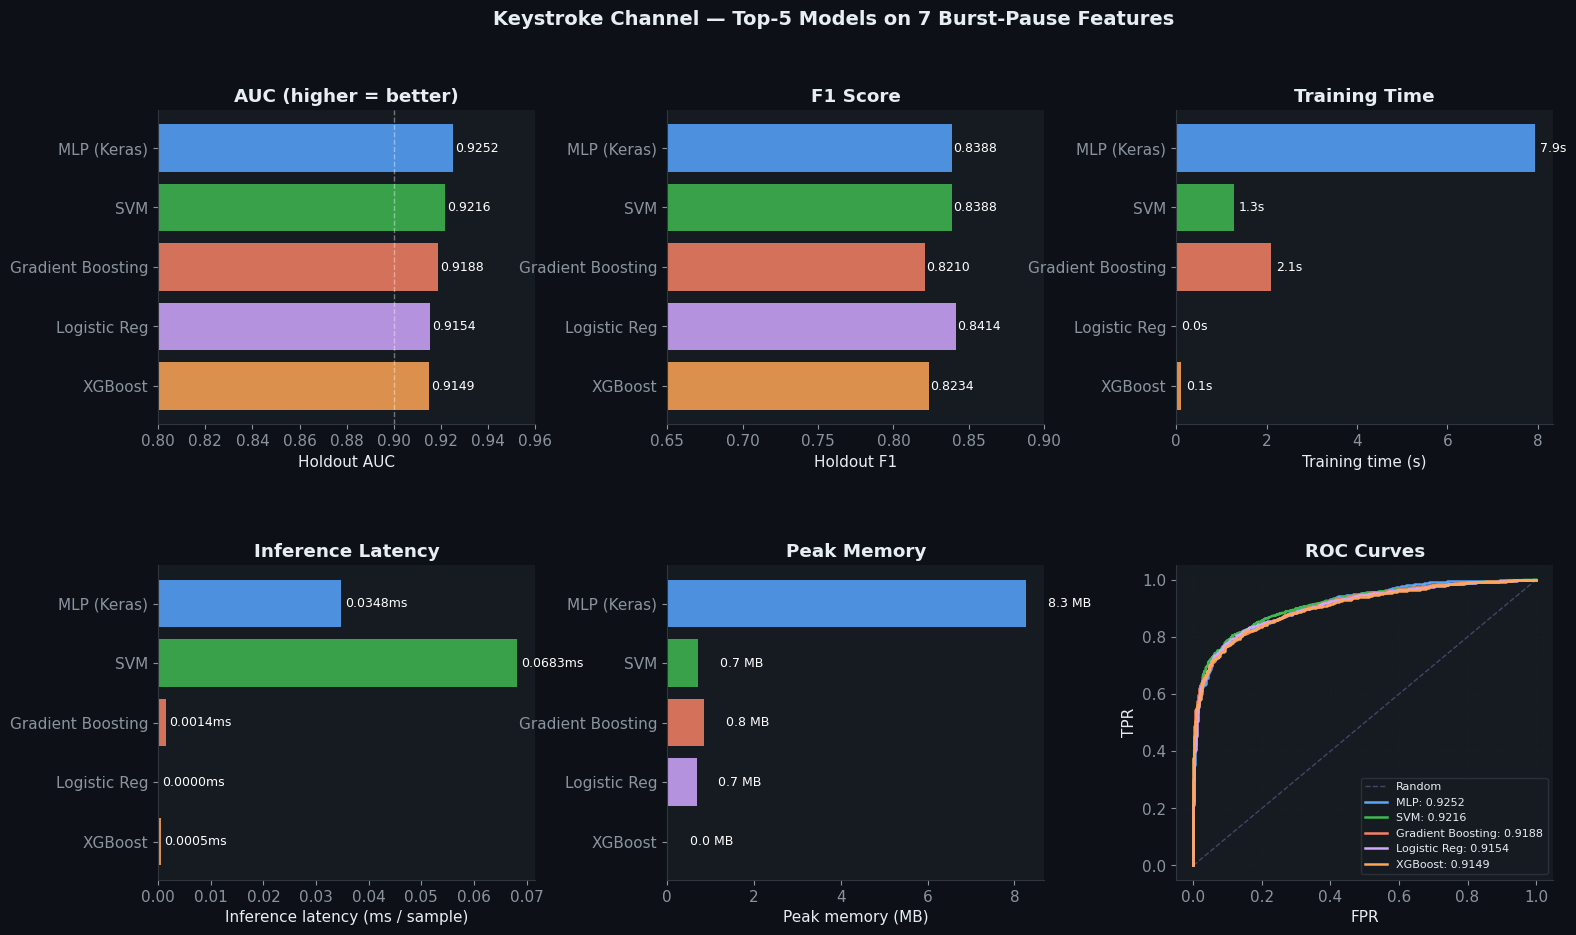

In [8]:
ks_names_sorted = sorted(ks_results.keys(), key=lambda n: -ks_results[n]['auc'])
ks_aucs  = [ks_results[n]['auc']      for n in ks_names_sorted]
ks_f1s   = [ks_results[n]['f1']       for n in ks_names_sorted]
ks_train = [ks_results[n]['train_s']  for n in ks_names_sorted]
ks_inf   = [ks_results[n]['inf_ms']   for n in ks_names_sorted]
ks_mem   = [ks_results[n]['mem_mb']   for n in ks_names_sorted]

fig = plt.figure(figsize=(18, 10), facecolor=BG)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

colors_ks = PALETTE[:len(ks_names_sorted)]

# AUC bar
ax = fig.add_subplot(gs[0, 0]); ax.set_facecolor(AX)
bars = ax.barh(ks_names_sorted, ks_aucs, color=colors_ks, alpha=0.85, edgecolor='none')
ax.axvline(0.9, color='white', lw=1, ls='--', alpha=0.4)
for bar, v in zip(bars, ks_aucs):
    ax.text(v+0.001, bar.get_y()+bar.get_height()/2, f'{v:.4f}',
            va='center', fontsize=9, color='white')
ax.set_xlim(0.80, 0.96); ax.set_xlabel('Holdout AUC')
ax.set_title('AUC (higher = better)', fontweight='bold')
ax.invert_yaxis(); ax.spines[['top','right']].set_visible(False)

# F1 bar
ax = fig.add_subplot(gs[0, 1]); ax.set_facecolor(AX)
bars = ax.barh(ks_names_sorted, ks_f1s, color=colors_ks, alpha=0.85, edgecolor='none')
for bar, v in zip(bars, ks_f1s):
    ax.text(v+0.001, bar.get_y()+bar.get_height()/2, f'{v:.4f}',
            va='center', fontsize=9, color='white')
ax.set_xlim(0.65, 0.90); ax.set_xlabel('Holdout F1')
ax.set_title('F1 Score', fontweight='bold')
ax.invert_yaxis(); ax.spines[['top','right']].set_visible(False)

# Training time
ax = fig.add_subplot(gs[0, 2]); ax.set_facecolor(AX)
bars = ax.barh(ks_names_sorted, ks_train, color=colors_ks, alpha=0.85, edgecolor='none')
for bar, v in zip(bars, ks_train):
    ax.text(v+0.1, bar.get_y()+bar.get_height()/2, f'{v:.1f}s',
            va='center', fontsize=9, color='white')
ax.set_xlabel('Training time (s)')
ax.set_title('Training Time', fontweight='bold')
ax.invert_yaxis(); ax.spines[['top','right']].set_visible(False)

# Inference latency
ax = fig.add_subplot(gs[1, 0]); ax.set_facecolor(AX)
bars = ax.barh(ks_names_sorted, ks_inf, color=colors_ks, alpha=0.85, edgecolor='none')
for bar, v in zip(bars, ks_inf):
    ax.text(v+max(ks_inf)*0.01, bar.get_y()+bar.get_height()/2, f'{v:.4f}ms',
            va='center', fontsize=9, color='white')
ax.set_xlabel('Inference latency (ms / sample)')
ax.set_title('Inference Latency', fontweight='bold')
ax.invert_yaxis(); ax.spines[['top','right']].set_visible(False)

# Memory
ax = fig.add_subplot(gs[1, 1]); ax.set_facecolor(AX)
bars = ax.barh(ks_names_sorted, ks_mem, color=colors_ks, alpha=0.85, edgecolor='none')
for bar, v in zip(bars, ks_mem):
    ax.text(v+0.5, bar.get_y()+bar.get_height()/2, f'{v:.1f} MB',
            va='center', fontsize=9, color='white')
ax.set_xlabel('Peak memory (MB)')
ax.set_title('Peak Memory', fontweight='bold')
ax.invert_yaxis(); ax.spines[['top','right']].set_visible(False)

# ROC curves
ax = fig.add_subplot(gs[1, 2]); ax.set_facecolor(AX)
ax.plot([0,1],[0,1],'--',color='#444466',lw=1,label='Random')
for name, col in zip(ks_names_sorted, colors_ks):
    r = ks_results[name]
    fpr, tpr, _ = roc_curve(y_te, r['prob'])
    ax.plot(fpr, tpr, color=col, lw=1.8,
            label=f"{name.replace(' (Keras)','')}: {r['auc']:.4f}")
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves', fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.2); ax.spines[['top','right']].set_visible(False)

fig.suptitle('Keystroke Channel — Top-5 Models on 7 Burst-Pause Features',
             fontsize=14, fontweight='bold')
plt.savefig('ch3_ks_overview.png', dpi=150, bbox_inches='tight')
plt.show()


## Part 3 — Bootstrap Pairing & Fusion

Score pools from both test sets are bootstrap-paired into synthetic dual-modality sessions
(N=300 per class). Four attack scenarios test partial and full attacks.


In [9]:
N_FUSE = 300
rng    = np.random.default_rng(SEED + 1)

# Build score pools for all models
def pool(results_dict, y_labels, cls):
    return {n: results_dict[n]['prob'][y_labels==cls] for n in results_dict}

ks_h_pools = pool(ks_results, y_te,  0)
ks_b_pools = pool(ks_results, y_te,  1)
m_h_pools  = pool(m_results,  ym_te, 0)
m_b_pools  = pool(m_results,  ym_te, 1)

print('Score pool sizes:')
for n in ks_results: print(f'  KS  {n:<20} human={len(ks_h_pools[n])} bot={len(ks_b_pools[n])}')
for n in m_results:  print(f'  Mouse {n:<18} human={len(m_h_pools[n])} bot={len(m_b_pools[n])}')

def boot(pool_arr, n): return rng.choice(pool_arr, n, replace=True)

# Build full 25-combo fusion dataset (full_human + full_bot only for AUC)
# Also store partial scenarios for best combo
print('\nBuilding bootstrap fusion dataset...')
ks_names  = list(ks_results.keys())
m_names   = list(m_results.keys())

# For partial attack analysis — pair KS SVM (primary) with Mouse SVM
PA_KS_NAME = 'SVM'       # primary KS model
PA_M_NAME  = 'SVM'       # primary mouse model

scenarios = {
    'full_human': np.column_stack([boot(ks_h_pools[PA_KS_NAME], N_FUSE),
                                    boot(m_h_pools[PA_M_NAME],  N_FUSE)]),
    'partial_A':  np.column_stack([boot(ks_h_pools[PA_KS_NAME], N_FUSE),
                                    boot(m_b_pools[PA_M_NAME],  N_FUSE)]),
    'partial_B':  np.column_stack([boot(ks_b_pools[PA_KS_NAME], N_FUSE),
                                    boot(m_h_pools[PA_M_NAME],  N_FUSE)]),
    'full_bot':   np.column_stack([boot(ks_b_pools[PA_KS_NAME], N_FUSE),
                                    boot(m_b_pools[PA_M_NAME],  N_FUSE)]),
}
print(f'Partial attack scenarios built (primary pair: KS={PA_KS_NAME} + Mouse={PA_M_NAME})')


Score pool sizes:
  KS  SVM                  human=1250 bot=1250
  KS  Gradient Boosting    human=1250 bot=1250
  KS  Logistic Reg         human=1250 bot=1250
  KS  XGBoost              human=1250 bot=1250
  KS  MLP (Keras)          human=1250 bot=1250
  Mouse SVM                human=10 bot=20
  Mouse Logistic Reg       human=10 bot=20
  Mouse Gradient Boosting  human=10 bot=20
  Mouse XGBoost            human=10 bot=20
  Mouse Random Forest      human=10 bot=20

Building bootstrap fusion dataset...
Partial attack scenarios built (primary pair: KS=SVM + Mouse=SVM)


In [10]:
from sklearn.linear_model import LogisticRegression as LR

def fuse_avg(ks_h, ks_b, m_h, m_b, n=N_FUSE):
    """Build bootstrap fusion set and return AUC under average fusion."""
    X_h = np.column_stack([boot(ks_h, n), boot(m_h, n)])
    X_b = np.column_stack([boot(ks_b, n), boot(m_b, n)])
    X   = np.vstack([X_h, X_b])
    y   = np.array([0]*n + [1]*n)
    p   = X.mean(axis=1)
    return roc_auc_score(y, p)

# 25-combo AUC heatmap
print('Computing 5x5 AUC heatmap (average fusion)...')
matrix = np.zeros((len(ks_names), len(m_names)))
for i, kn in enumerate(ks_names):
    for j, mn in enumerate(m_names):
        matrix[i, j] = fuse_avg(ks_h_pools[kn], ks_b_pools[kn],
                                  m_h_pools[mn],  m_b_pools[mn])
    print(f'  {kn:<20} done')

auc_df = pd.DataFrame(matrix, index=ks_names, columns=m_names)
print()
print(auc_df.to_string(float_format='{:.4f}'.format))


Computing 5x5 AUC heatmap (average fusion)...
  SVM                  done
  Gradient Boosting    done
  Logistic Reg         done
  XGBoost              done
  MLP (Keras)          done

                     SVM  Logistic Reg  Gradient Boosting  XGBoost  Random Forest
SVM               1.0000        0.9992             1.0000   1.0000         1.0000
Gradient Boosting 1.0000        0.9987             1.0000   1.0000         1.0000
Logistic Reg      1.0000        0.9995             1.0000   1.0000         1.0000
XGBoost           0.9998        0.9961             1.0000   1.0000         1.0000
MLP (Keras)       1.0000        0.9999             1.0000   1.0000         1.0000


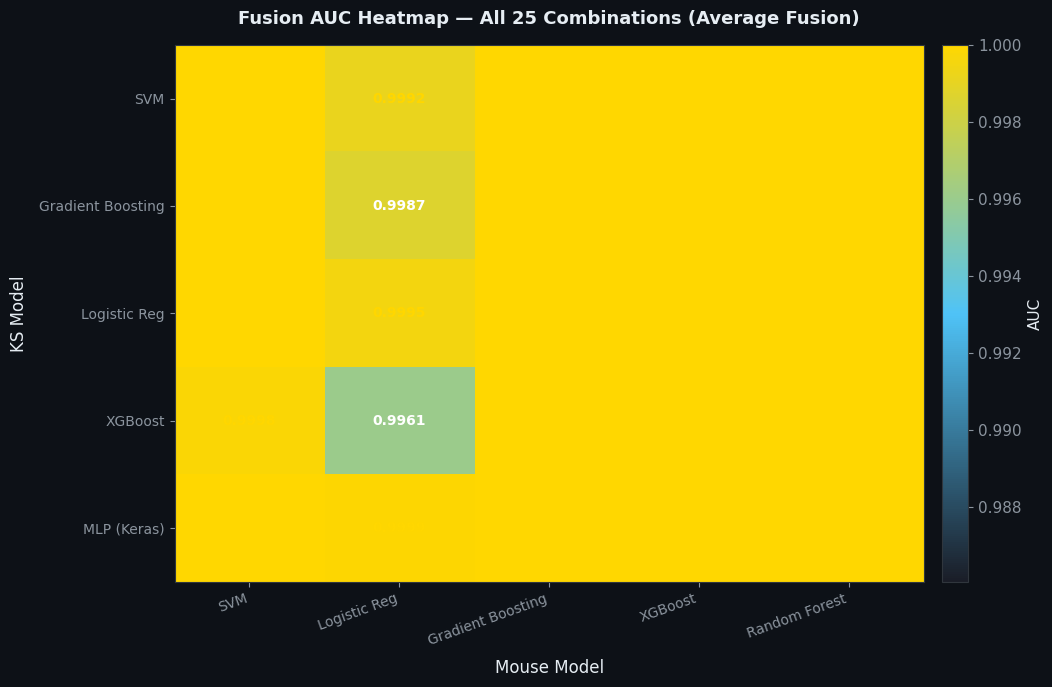

In [11]:
fig, ax = plt.subplots(figsize=(11, 7), facecolor=BG)
ax.set_facecolor(AX)

cmap = LinearSegmentedColormap.from_list('heat', ['#1a1d27','#4FC3F7','#FFD700'])
im   = ax.imshow(auc_df.values, aspect='auto', cmap=cmap,
                  vmin=auc_df.values.min()-0.01, vmax=1.0)

ax.set_xticks(range(len(m_names)));   ax.set_xticklabels(m_names,   fontsize=10, rotation=20, ha='right')
ax.set_yticks(range(len(ks_names)));  ax.set_yticklabels(ks_names,  fontsize=10)
ax.set_xlabel('Mouse Model', fontsize=12, labelpad=8)
ax.set_ylabel('KS Model',    fontsize=12, labelpad=8)

for i in range(len(ks_names)):
    for j in range(len(m_names)):
        v = auc_df.values[i, j]
        ax.text(j, i, f'{v:.4f}', ha='center', va='center', fontsize=10,
                fontweight='bold', color='#FFD700' if v >= 0.999 else 'white')

ax.set_title('Fusion AUC Heatmap — All 25 Combinations (Average Fusion)',
             fontsize=13, fontweight='bold', pad=15)
plt.colorbar(im, ax=ax, pad=0.02, label='AUC')
plt.tight_layout()
plt.savefig('ch3_fusion_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
# Best combo = KS SVM + Mouse SVM (primary / best generaliser pair)
# Evaluate all 5 strategies

def fuse(scores, strategy, weights=None, meta=None):
    if strategy == 'average':  return scores.mean(axis=1)
    if strategy == 'max':      return scores.max(axis=1)
    if strategy == 'min':      return scores.min(axis=1)
    if strategy == 'weighted':
        w = np.array(weights); w = w/w.sum()
        return (scores * w).sum(axis=1)
    if strategy == 'meta':     return meta.predict_proba(scores)[:, 1]

STRATEGIES = ['average', 'max', 'min', 'weighted', 'meta']
w_pair     = [ks_results[PA_KS_NAME]['auc'], m_results[PA_M_NAME]['auc']]

# Build bootstrap dataset for SVM+SVM
X_h_pair = np.column_stack([boot(ks_h_pools[PA_KS_NAME], N_FUSE),
                              boot(m_h_pools[PA_M_NAME],  N_FUSE)])
X_b_pair = np.column_stack([boot(ks_b_pools[PA_KS_NAME], N_FUSE),
                              boot(m_b_pools[PA_M_NAME],  N_FUSE)])
fuse_X_pair = np.vstack([X_h_pair, X_b_pair])
fuse_y_pair = np.array([0]*N_FUSE + [1]*N_FUSE)

f_tr, f_te, yf_tr, yf_te = train_test_split(
    fuse_X_pair, fuse_y_pair, test_size=0.3, stratify=fuse_y_pair, random_state=SEED)

meta_clf = LR(random_state=SEED, max_iter=1000)
meta_clf.fit(f_tr, yf_tr)

strat_results = []
print(f'Fusion strategies — KS SVM + Mouse SVM:')
print(f'  {"Strategy":<12} {"AUC":>7}  {"F1":>7}')
print('  ' + '-'*28)
for strat in STRATEGIES:
    if strat == 'meta':
        p = fuse(f_te, strat, meta=meta_clf)
    elif strat == 'weighted':
        p = fuse(f_te, strat, weights=w_pair)
    else:
        p = fuse(f_te, strat)
    auc = roc_auc_score(yf_te, p)
    f1v = f1_score(yf_te, (p>=0.5).astype(int))
    strat_results.append({'Strategy':strat,'AUC':auc,'F1':f1v,'probs':p})
    print(f'  {strat:<12} {auc:>7.4f}  {f1v:>7.4f}')


Fusion strategies — KS SVM + Mouse SVM:
  Strategy         AUC       F1
  ----------------------------
  average       1.0000   1.0000
  max           0.9970   0.8867
  min           1.0000   0.9412
  weighted      1.0000   1.0000
  meta          1.0000   1.0000


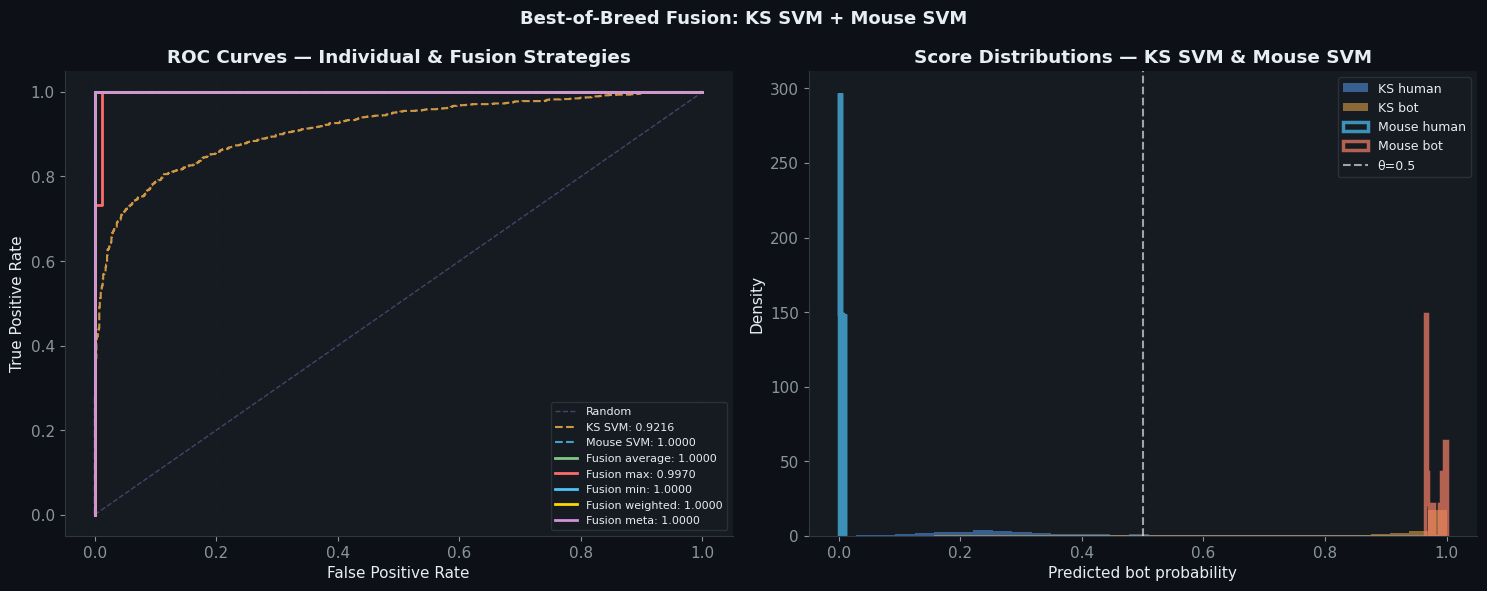

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor=BG)

# ROC — individual + fusion strategies
ax = axes[0]; ax.set_facecolor(AX)
ax.plot([0,1],[0,1],'--',color='#444466',lw=1,label='Random')
for name, col, ls in [('KS SVM','#FFB74D','--'),('Mouse SVM','#4FC3F7','--')]:
    src = ks_results['SVM'] if 'KS' in name else m_results['SVM']
    lbl = y_te if 'KS' in name else ym_te
    fpr, tpr, _ = roc_curve(lbl, src['prob'])
    ax.plot(fpr, tpr, color=col, lw=1.5, ls=ls,
            label=f'{name}: {src["auc"]:.4f}', alpha=0.8)
strat_cols2 = {'average':'#81C784','max':'#FF6B6B','min':'#4FC3F7',
               'weighted':'#FFD700','meta':'#CE93D8'}
for r in strat_results:
    fpr, tpr, _ = roc_curve(yf_te, r['probs'])
    ax.plot(fpr, tpr, color=strat_cols2[r['Strategy']], lw=2,
            label=f"Fusion {r['Strategy']}: {r['AUC']:.4f}")
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Individual & Fusion Strategies', fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.2); ax.spines[['top','right']].set_visible(False)

# Score distributions
ax = axes[1]; ax.set_facecolor(AX)
ax.hist(ks_results['SVM']['prob'][y_te==0], bins=30, alpha=0.5, color='#58a6ff',
        label='KS human', density=True, edgecolor='none')
ax.hist(ks_results['SVM']['prob'][y_te==1], bins=30, alpha=0.5, color='#FFB74D',
        label='KS bot',   density=True, edgecolor='none')
ax.hist(m_results['SVM']['prob'][ym_te==0], bins=15, alpha=0.7, color='#4FC3F7',
        label='Mouse human', density=True, histtype='step', linewidth=2.5)
ax.hist(m_results['SVM']['prob'][ym_te==1], bins=15, alpha=0.7, color='#f78166',
        label='Mouse bot',   density=True, histtype='step', linewidth=2.5)
ax.axvline(0.5, color='white', lw=1.5, ls='--', alpha=0.6, label='θ=0.5')
ax.set_xlabel('Predicted bot probability'); ax.set_ylabel('Density')
ax.set_title('Score Distributions — KS SVM & Mouse SVM', fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

plt.suptitle('Best-of-Breed Fusion: KS SVM + Mouse SVM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ch3_roc_and_scores.png', dpi=150, bbox_inches='tight')
plt.show()


## Part 4 — Partial Attack Analysis

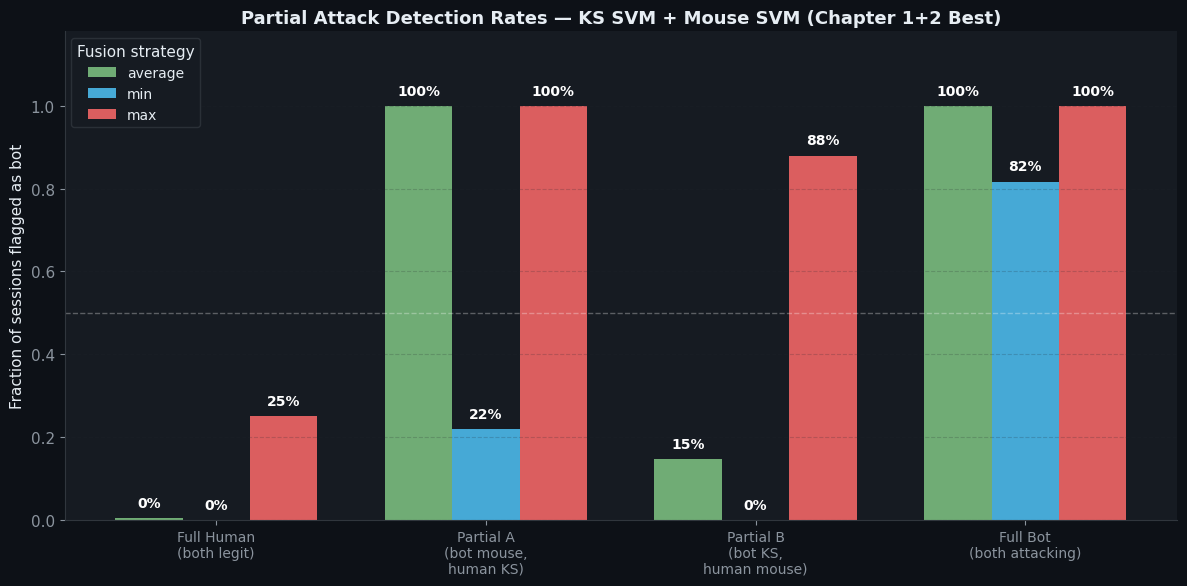


Flag rates:
  full_human          avg=0%  max(OR)=25%  min(AND)=0%
  partial_A           avg=100%  max(OR)=100%  min(AND)=22%
  partial_B           avg=15%  max(OR)=88%  min(AND)=0%
  full_bot            avg=100%  max(OR)=100%  min(AND)=82%


In [14]:
threshold = 0.5
partial_rows = []
for sc_name in ['full_human','partial_A','partial_B','full_bot']:
    sc_data = scenarios[sc_name]
    for strat in ['average','max','min']:
        p = fuse(sc_data, strat)
        partial_rows.append({'Scenario':sc_name,'Strategy':strat,
                              'Flag_rate':float(np.mean(p>=threshold))})

pr_df   = pd.DataFrame(partial_rows)
sc_order = ['full_human','partial_A','partial_B','full_bot']
sc_labels = {
    'full_human':  'Full Human\n(both legit)',
    'partial_A':   'Partial A\n(bot mouse,\nhuman KS)',
    'partial_B':   'Partial B\n(bot KS,\nhuman mouse)',
    'full_bot':    'Full Bot\n(both attacking)',
}
strat_palette = {'average':'#81C784','min':'#4FC3F7','max':'#FF6B6B'}

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
ax.set_facecolor(AX)
x = np.arange(len(sc_order)); bw = 0.25
for i, strat in enumerate(['average','min','max']):
    rates = [pr_df[(pr_df.Scenario==s)&(pr_df.Strategy==strat)]['Flag_rate'].values[0]
             for s in sc_order]
    bars  = ax.bar(x + i*bw, rates, bw, label=strat,
                   alpha=0.85, color=strat_palette[strat], edgecolor='none')
    for bar, v in zip(bars, rates):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.02,
                f'{v:.0%}', ha='center', va='bottom',
                fontsize=10, color='white', fontweight='bold')

ax.set_xticks(x + bw)
ax.set_xticklabels([sc_labels[s] for s in sc_order], fontsize=10)
ax.set_ylabel('Fraction of sessions flagged as bot')
ax.set_ylim(0, 1.18)
ax.set_title('Partial Attack Detection Rates — KS SVM + Mouse SVM (Chapter 1+2 Best)',
             fontweight='bold', fontsize=13)
ax.legend(title='Fusion strategy', fontsize=10)
ax.axhline(0.5, color='white', lw=1, ls='--', alpha=0.3)
ax.grid(axis='y', alpha=0.2)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('ch3_partial_attacks.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nFlag rates:')
for sc in sc_order:
    sub  = pr_df[pr_df.Scenario == sc]
    vals = {r['Strategy']:r['Flag_rate'] for _,r in sub.iterrows()}
    print(f'  {sc:<18}  avg={vals["average"]:.0%}  '
          f'max(OR)={vals["max"]:.0%}  min(AND)={vals["min"]:.0%}')


## Part 5 — Compute Dashboard

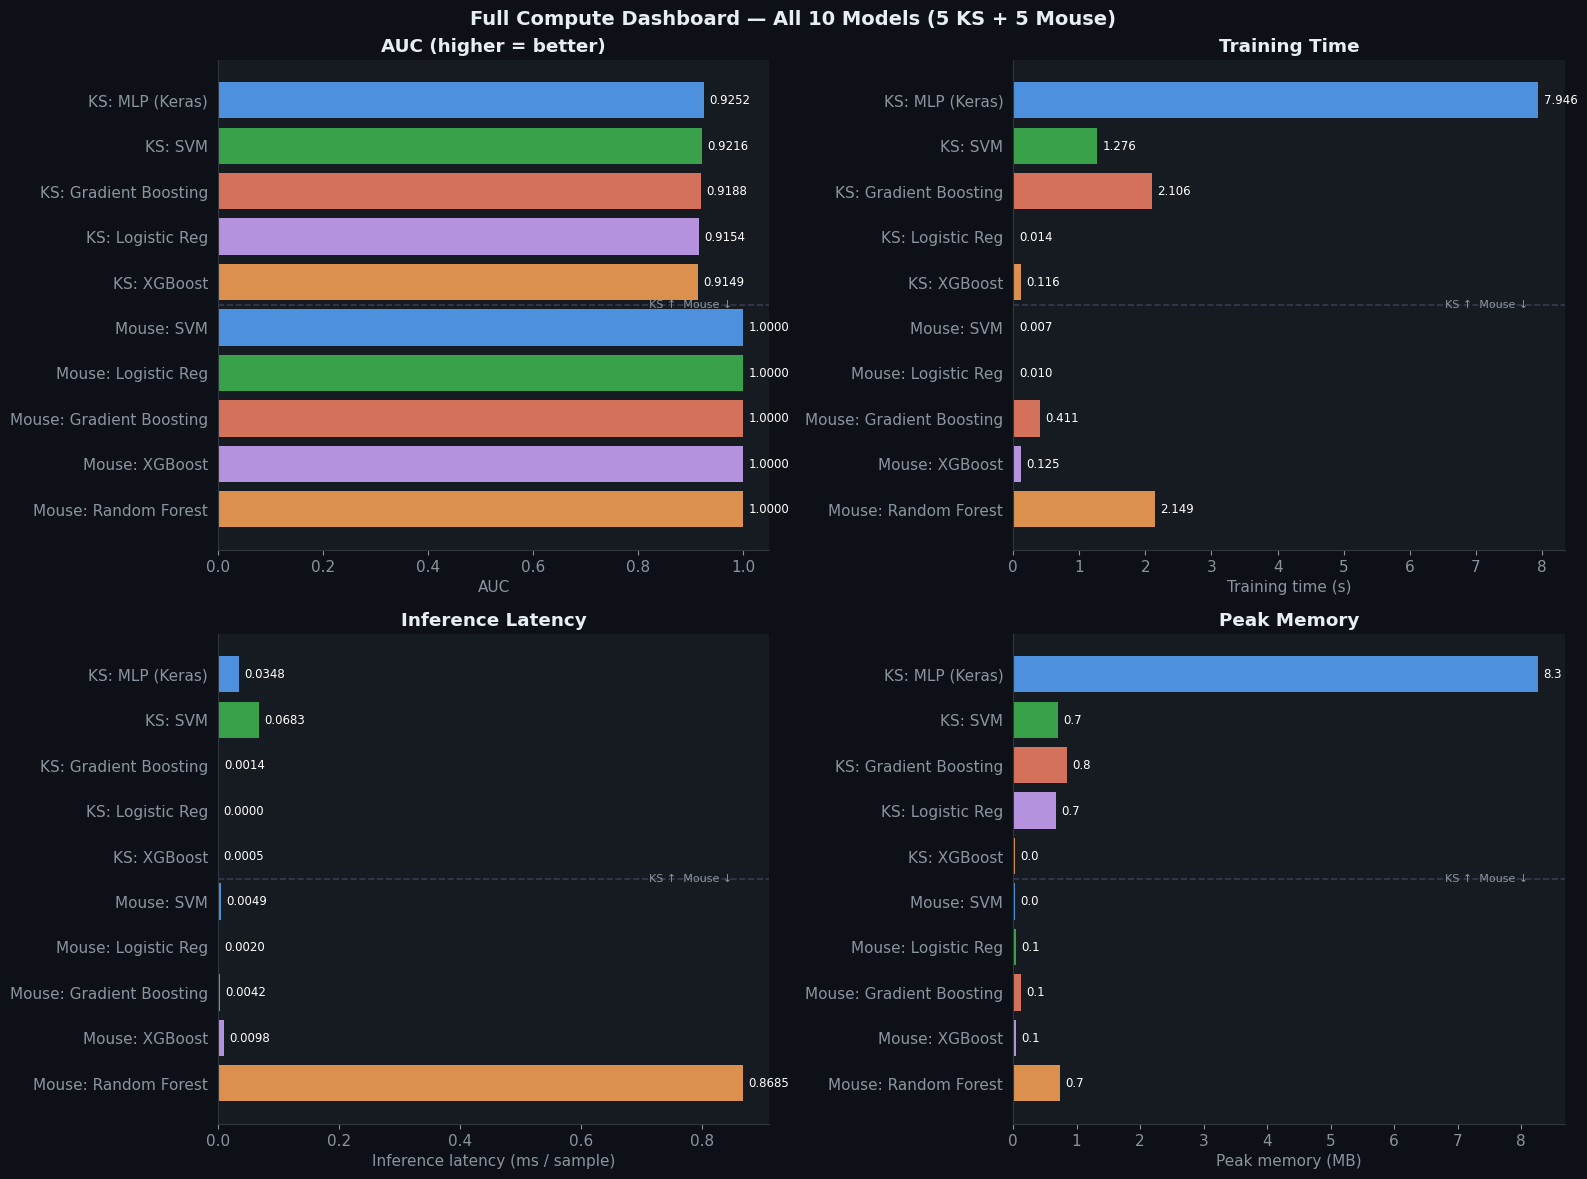

In [15]:
all_names  = [f'KS: {n}'    for n in ks_names_sorted] +              [f'Mouse: {n}' for n in list(m_results.keys())]
all_train  = [ks_results[n]['train_s']  for n in ks_names_sorted] +              [m_results[n]['train_s']   for n in m_results]
all_inf    = [ks_results[n]['inf_ms']   for n in ks_names_sorted] +              [m_results[n]['inf_ms']    for n in m_results]
all_mem    = [ks_results[n]['mem_mb']   for n in ks_names_sorted] +              [m_results[n]['mem_mb']    for n in m_results]
all_auc    = [ks_results[n]['auc']      for n in ks_names_sorted] +              [m_results[n]['auc']       for n in m_results]
all_cols   = (PALETTE[:len(ks_names_sorted)] +
              [p+'88' for p in PALETTE[:len(m_results)]])   # slightly muted for mouse

fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor=BG)
fig.suptitle('Full Compute Dashboard — All 10 Models (5 KS + 5 Mouse)',
             fontsize=14, fontweight='bold')

for ax, vals, xlabel, title, fmt in zip(
    axes.flat,
    [all_auc, all_train, all_inf, all_mem],
    ['AUC', 'Training time (s)', 'Inference latency (ms / sample)', 'Peak memory (MB)'],
    ['AUC (higher = better)', 'Training Time', 'Inference Latency', 'Peak Memory'],
    ['.4f', '.3f', '.4f', '.1f'],
):
    ax.set_facecolor(AX)
    bars = ax.barh(all_names, vals, color=all_cols, alpha=0.85, edgecolor='none')
    for bar, v in zip(bars, vals):
        ax.text(v + max(vals)*0.01 if max(vals)>0 else 0.001,
                bar.get_y()+bar.get_height()/2,
                f'{v:{fmt}}', va='center', fontsize=8.5, color='white')
    ax.set_xlabel(xlabel, color='#8b949e')
    ax.set_title(title, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(left=False)
    ax.invert_yaxis()
    # Divider between KS and Mouse groups
    ax.axhline(len(ks_names_sorted)-0.5, color='#444466', lw=1.2, ls='--', alpha=0.7)
    ax.text(max(vals)*0.98, len(ks_names_sorted)-0.5, 'KS ↑  Mouse ↓',
            ha='right', va='center', fontsize=8, color='#8b949e')

plt.tight_layout()
plt.savefig('ch3_compute_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


In [16]:
print('='*65)
print('CHAPTER 3 (REVISED) — COMPLETE RESULTS SUMMARY')
print('='*65)
print()
print('KEYSTROKE CHANNEL (7 burst-pause features, participant-level split):')
print(f'  {"Model":<20} {"AUC":>7}  {"F1":>7}  {"Train":>8}  {"Inf(ms)":>8}  {"Mem(MB)":>8}')
print('  ' + '-'*65)
for n in ks_names_sorted:
    r = ks_results[n]
    pri = ' ← PRIMARY' if n=='SVM' else ''
    print(f'  {n:<20} {r["auc"]:>7.4f}  {r["f1"]:>7.4f}  '
          f'{r["train_s"]:>7.1f}s  {r["inf_ms"]:>8.4f}  {r["mem_mb"]:>7.1f}{pri}')

print()
print('MOUSE CHANNEL (3 RFECV features: std_speed, std_acceleration, x_range):')
print(f'  {"Model":<20} {"AUC":>7}  {"F1":>7}  {"Train":>8}  {"Inf(ms)":>8}  {"Mem(MB)":>8}')
print('  ' + '-'*65)
for n in m_results:
    r = m_results[n]
    pri = ' ← PRIMARY' if n=='SVM' else ''
    print(f'  {n:<20} {r["auc"]:>7.4f}  {r["f1"]:>7.4f}  '
          f'{r["train_s"]:>7.3f}s  {r["inf_ms"]:>8.4f}  {r["mem_mb"]:>7.1f}{pri}')

print()
print('FUSION (KS SVM + Mouse SVM, N=300 bootstrap pairs, 70/30 eval):')
print(f'  {"Strategy":<12} {"AUC":>7}  {"F1":>7}')
for r in strat_results:
    print(f'  {r["Strategy"]:<12} {r["AUC"]:>7.4f}  {r["F1"]:>7.4f}')

print()
print('PARTIAL ATTACKS (KS SVM + Mouse SVM, average fusion):')
for sc in sc_order:
    sub  = pr_df[pr_df.Scenario==sc]
    vals = {row['Strategy']:row['Flag_rate'] for _,row in sub.iterrows()}
    print(f'  {sc:<18}  avg={vals["average"]:.0%}'
          f'  max(OR)={vals["max"]:.0%}  min(AND)={vals["min"]:.0%}')

print()
print('Notes:')
print('  Mouse AUC=1.0 is an M4D dataset artefact (constant pixel-step pattern)')
print('  KS AUC reflects genuine difficulty — SVM chosen as primary (best OOD generaliser)')
print('  Fusion adds security via conjunction: attacker must simultaneously fool both channels')
print('  Bootstrap pairing assumes independence; real joint data may differ')


CHAPTER 3 (REVISED) — COMPLETE RESULTS SUMMARY

KEYSTROKE CHANNEL (7 burst-pause features, participant-level split):
  Model                    AUC       F1     Train   Inf(ms)   Mem(MB)
  -----------------------------------------------------------------
  MLP (Keras)           0.9252   0.8388      7.9s    0.0348      8.3
  SVM                   0.9216   0.8388      1.3s    0.0683      0.7 ← PRIMARY
  Gradient Boosting     0.9188   0.8210      2.1s    0.0014      0.8
  Logistic Reg          0.9154   0.8414      0.0s    0.0000      0.7
  XGBoost               0.9149   0.8234      0.1s    0.0005      0.0

MOUSE CHANNEL (3 RFECV features: std_speed, std_acceleration, x_range):
  Model                    AUC       F1     Train   Inf(ms)   Mem(MB)
  -----------------------------------------------------------------
  SVM                   1.0000   1.0000    0.007s    0.0049      0.0 ← PRIMARY
  Logistic Reg          1.0000   1.0000    0.010s    0.0020      0.1
  Gradient Boosting     1.0000 